In [1]:
import pandas as pd
import numpy as np
%matplotlib inline 

import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
transaction_data = R"C:\Users\venta\Documents\Grad Plans\portfolio\Quantium\QVI_transaction_data.csv"
df_transaction = pd.read_csv(transaction_data, header=0)
df_transaction.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [3]:
customer_data = R"C:\Users\venta\Documents\Grad Plans\portfolio\Quantium\QVI_purchase_behaviour.csv"
df_customer = pd.read_csv(customer_data, header=0)
df_customer.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [4]:
df_transaction.dtypes #verifying feature types correct
df_transaction.shape #checking rows and columns

(264836, 8)

In [5]:
df_transaction['DATE'] = pd.to_datetime(df_transaction['DATE'], unit='D', origin='1899-12-30')

In [6]:
with pd.option_context('display.max_rows', None): #pandas being conservative with output
    print(df_transaction['PROD_NAME'].value_counts()) #identifying non-chip items:

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
Kettle 135g Swt Pot Sea Salt                3257
Tostitos Splash Of  Lime 175g               3252
Infuzions Thai SweetChili PotatoMix 110g    3242
Smiths Crnkle Chip  Orgnl Big Bag 380g      3233
Thins Potato Chips  Hot & Spicy 175g        3229
Kettle Sensations   Camembert & Fig 150g    3219
Doritos Corn Chips  Cheese Supreme 170g     3217
Pringles Barbeque   134g                    3210
Doritos Corn Chip Mexican Jalapeno 150g     3204
Kettle Sweet Chilli And Sour Cream 175g     3200
Smiths Crinkle Chips Salt & Vinegar 330g    3197
Thins Chips Light&  Tangy 175g              3188
Dorito Corn Chp     Supreme 380g            3185
Pringles Sweet&Spcy BBQ 134g                3177
Infuzions BBQ Rib   Prawn Crackers 110g     3174
Tyrrells C

In [7]:
df_transaction['PROD_NAME'].describe()

count                                     264836
unique                                       114
top       Kettle Mozzarella   Basil & Pesto 175g
freq                                        3304
Name: PROD_NAME, dtype: object

In [8]:
#separating words, removing characters and digits
product_words = df_transaction['PROD_NAME'].str.split().explode()
print(product_words)
product_words = product_words[product_words.str.isalpha()]
with pd.option_context('display.max_rows', None): 
    print(product_words.value_counts())

0             Natural
0                Chip
0              Compny
0         SeaSalt175g
1                 CCs
             ...     
264835       Tostitos
264835         Splash
264835             Of
264835           Lime
264835           175g
Name: PROD_NAME, Length: 1359084, dtype: str
PROD_NAME
Chips              49770
Kettle             41288
Smiths             28860
Salt               27976
Cheese             27890
Pringles           25102
Doritos            24962
Crinkle            23960
Corn               22063
Original           21560
Cut                20754
Chip               18645
Salsa              18094
Chicken            15407
Sea                14145
Thins              14075
Sour               13882
Crisps             12607
Vinegar            12402
Chilli             12389
RRD                11894
Infuzions          11057
Supreme            10963
WW                 10320
Cobs                9693
Popd                9693
Tortilla            9580
Tostitos            9471
Twi

In [9]:
df_transaction[df_transaction['PROD_NAME'].str.contains('Dip', case=False)]['PROD_NAME'].unique()
#note, dip appears to be a flavor, while salsa seems to be literal salsa

<StringArray>
['Old El Paso Salsa   Dip Tomato Mild 300g',
 'Smiths Crinkle Cut  French OnionDip 150g',
 'Old El Paso Salsa   Dip Chnky Tom Ht300g',
  'Old El Paso Salsa   Dip Tomato Med 300g']
Length: 4, dtype: str

In [10]:
#removing salsa items:
df_transaction = df_transaction[~df_transaction['PROD_NAME'].str.lower().str.contains("salsa")]


In [11]:
print(df_transaction.shape)
print(df_transaction.isnull().sum())

(246742, 8)
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64


In [12]:
#removing excess delimiter spacing
df_transaction['PROD_NAME'] = df_transaction['PROD_NAME'].str.replace(r'\s+', ' ', regex=True).str.strip()
df_transaction['PROD_NAME'].head()

0             Natural Chip Compny SeaSalt175g
1                       CCs Nacho Cheese 175g
2       Smiths Crinkle Cut Chips Chicken 170g
3       Smiths Chip Thinly S/Cream&Onion 175g
4    Kettle Tortilla ChpsHny&Jlpno Chili 150g
Name: PROD_NAME, dtype: str

In [13]:
df_transaction[['PROD_QTY', 'TOT_SALES']].describe() #checking for outliers

,PROD_QTY,TOT_SALES
count,246742.000000,246742.000000
mean,1.908062,7.321322
std,0.659831,3.077828
min,1.000000,1.700000
25%,2.000000,5.800000
50%,2.000000,7.400000
75%,2.000000,8.800000
max,200.000000,650.000000


In [14]:
#checking for other outliers
df_transaction['PROD_QTY'].value_counts().sort_index(ascending=False)

PROD_QTY
200         2
5         415
4         371
3         408
2      220070
1       25476
Name: count, dtype: int64

In [15]:
df_transaction['TOT_SALES'].value_counts().sort_index(ascending=False)

TOT_SALES
650.0      2
29.5       7
28.5      12
27.0      35
23.6       4
        ... 
2.3      186
2.1      732
1.9      930
1.8      175
1.7      708
Name: count, Length: 105, dtype: int64

In [16]:
df_transaction[df_transaction['PROD_QTY'] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [17]:
#identified outlier same purchaser
outlier_card = 226000
df_transaction = df_transaction[df_transaction['LYLTY_CARD_NBR'] != outlier_card]
df_transaction['PROD_QTY'].describe()

count    246740.000000
mean          1.906456
std           0.342499
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           5.000000
Name: PROD_QTY, dtype: float64

In [18]:
#summary by dates
df_transaction['DATE'].value_counts().sort_index()

DATE
2018-07-01    663
2018-07-02    650
2018-07-03    674
2018-07-04    669
2018-07-05    660
             ... 
2019-06-26    657
2019-06-27    669
2019-06-28    673
2019-06-29    703
2019-06-30    704
Name: count, Length: 364, dtype: int64

In [19]:
#count transactions by date to look for gaps i.e., christmas
#since 364 indicates one missing date

#counts by date df
df_counts = df_transaction.groupby('DATE').size().reset_index(name='N') #puts date in standard column and list of counts to N
df_counts

,DATE,N
0,2018-07-01,663
1,2018-07-02,650
2,2018-07-03,674
3,2018-07-04,669
4,2018-07-05,660
...,...,...
359,2019-06-26,657
360,2019-06-27,669
361,2019-06-28,673
362,2019-06-29,703


In [20]:
#date range sequence
full_range = pd.date_range(start=df_counts['DATE'].min(), end=df_counts['DATE'].max())
full_range

DatetimeIndex(['2018-07-01', '2018-07-02', '2018-07-03', '2018-07-04',
               '2018-07-05', '2018-07-06', '2018-07-07', '2018-07-08',
               '2018-07-09', '2018-07-10',
               ...
               '2019-06-21', '2019-06-22', '2019-06-23', '2019-06-24',
               '2019-06-25', '2019-06-26', '2019-06-27', '2019-06-28',
               '2019-06-29', '2019-06-30'],
              dtype='datetime64[s]', length=365, freq='D')

In [21]:
#dataframe w range and counts to fill the NaN for dec 25
transactions_by_day = pd.DataFrame(full_range, columns=['DATE']).merge(df_counts, on='DATE', how='left').fillna(0)
transactions_by_day

,DATE,N
0,2018-07-01,663.0
1,2018-07-02,650.0
2,2018-07-03,674.0
3,2018-07-04,669.0
4,2018-07-05,660.0
...,...,...
360,2019-06-26,657.0
361,2019-06-27,669.0
362,2019-06-28,673.0
363,2019-06-29,703.0


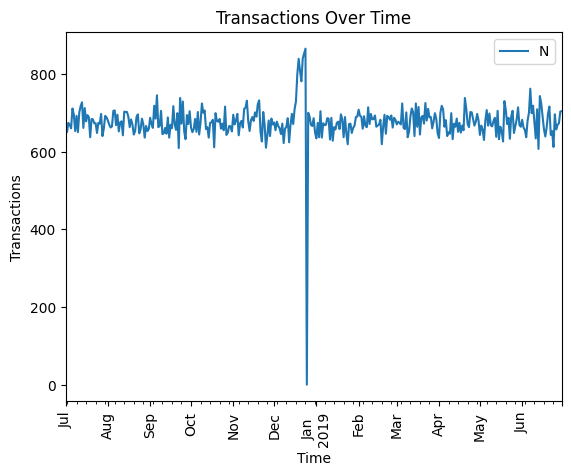

In [22]:
transactions_by_day.plot(kind='line', x='DATE', y='N',rot=90)
plt.title('Transactions Over Time')
plt.xlabel('Time')
plt.ylabel('Transactions')
transactions_by_day.to_csv('pretrial_transactions.csv', index=False)

In [23]:
#zooming in on December
december_data = transactions_by_day[transactions_by_day['DATE'].dt.month == 12]
december_data.shape
#exporting for excel
december_data.to_csv('december_data.csv', index=False)

Text(0, 0.5, 'Transactions')

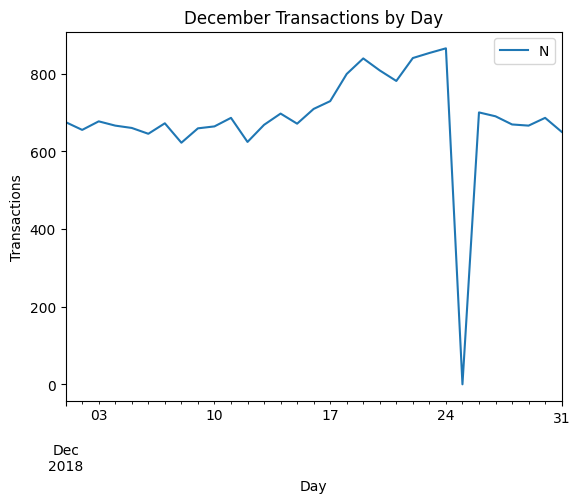

In [24]:
december_data.plot(kind='line', x='DATE', y='N')
plt.title('December Transactions by Day')
plt.xlabel('Day')
plt.ylabel('Transactions')

In [138]:
#separating bag size digits from product name
df_transaction['PACK_SIZE'] = df_transaction['PROD_NAME'].str.extract(r'(\d+)').astype(float)
df_transaction.shape

(246740, 9)

In [142]:
#removing pack sizes digits followed by g or G from names
df_transaction['PROD_NAME'] = df_transaction['PROD_NAME'].str.replace(r'\d+[gG]', '', regex=True)
df_transaction[['PROD_NAME', 'PACK_SIZE']].head()

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt,175.0
1,CCs Nacho Cheese,175.0
2,Smiths Crinkle Cut Chips Chicken,170.0
3,Smiths Chip Thinly S/Cream&Onion,175.0
4,Kettle Tortilla ChpsHny&Jlpno Chili,150.0


In [143]:
#checking for sensibility
df_transaction['PACK_SIZE'].describe()

count    246740.000000
mean        175.583521
std          59.432118
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64

Text(0, 0.5, 'Transactions')

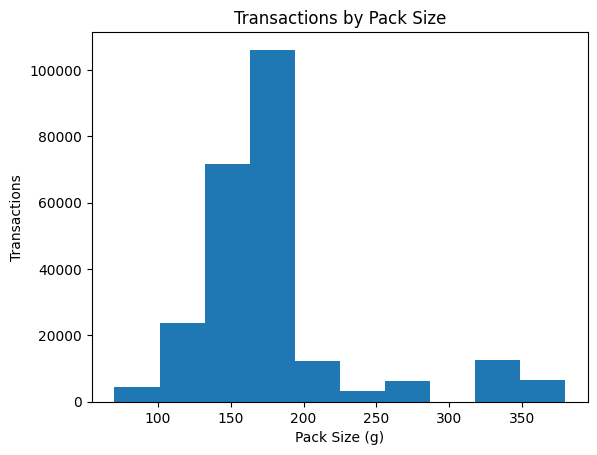

In [145]:
#histogram for categorical variable
df_transaction['PACK_SIZE'].plot(kind='hist')
plt.title('Transactions by Pack Size')
plt.xlabel('Pack Size (g)')
plt.ylabel('Transactions')

In [148]:
#separating brand name from product name by spliting the first worm
df_transaction['BRAND'] = df_transaction['PROD_NAME'].str.split().str[0]
#removing first word from PROD_NAME
df_transaction['PROD_NAME'] = df_transaction['PROD_NAME'].str.split(n=1).str[1]
df_transaction[['PROD_NAME', 'BRAND']].head()

,PROD_NAME,BRAND
0,Chip Compny SeaSalt,Natural
1,Nacho Cheese,CCs
2,Crinkle Cut Chips Chicken,Smiths
3,Chip Thinly S/Cream&Onion,Smiths
4,Tortilla ChpsHny&Jlpno Chili,Kettle


In [151]:
#examining errors in brand names
print(df_transaction['BRAND'].value_counts())

BRAND
Kettle        41288
Smiths        27390
Pringles      25102
Doritos       22041
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Tyrrells       6442
Grain          6272
Natural        6050
Cheezels       4603
CCs            4551
Red            4427
Dorito         3183
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
Woolworths     1516
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64


In [161]:
#Smith and Smiths, Dorito and Doritos, RRD and Red, WW and Woolworths, GrnWves and Grain
#Snbts and Sunbites, Infzns and Infuzions. 
#checking to ensure NCC 
print(df_transaction[df_transaction['BRAND'] == 'Natural']['PROD_NAME'].unique())
print(df_transaction[df_transaction['BRAND'] == 'NCC']['PROD_NAME'].unique())

['Chip Compny SeaSalt' 'ChipCo Hony Soy Chckn' 'Chip Co Tmato Hrb&Spce '
 'ChipCo Sea Salt & Vinegr ']
['Sour Cream & Garden Chives ']


In [163]:
#brand corrections dictionary
brand_corrections = {'Red':'RRD', 'Smith':'Smiths', 'Dorito':'Doritos', 'WW':'Woolworths', 'GrnWves':'Grain', 'Snbts':'Sunbites', 'Infzns':'Infuzions', 'NCC': 'Natural'}
#replacement
df_transaction['BRAND'] = df_transaction['BRAND'].replace(brand_corrections)
df_transaction['BRAND'].value_counts()

BRAND
Kettle        41288
Smiths        30353
Doritos       25224
Pringles      25102
RRD           16321
Infuzions     14201
Thins         14075
Woolworths    11836
Cobs           9693
Tostitos       9471
Twisties       9454
Grain          7740
Natural        7469
Tyrrells       6442
Cheezels       4603
CCs            4551
Sunbites       3008
Cheetos        2927
Burger         1564
French         1418
Name: count, dtype: int64

In [174]:
df_transaction[['PROD_QTY', 'TOT_SALES', 'PACK_SIZE', 'PROD_NAME', 'BRAND']].describe(include='all')

,PROD_QTY,TOT_SALES,PACK_SIZE,PROD_NAME,BRAND
count,246740.000000,246740.000000,246740.000000,246740,246740
unique,NaN,NaN,NaN,102,20
top,NaN,NaN,NaN,Cheese,Kettle
freq,NaN,NaN,NaN,6264,41288
mean,1.906456,7.316113,175.583521,NaN,NaN
std,0.342499,2.474897,59.432118,NaN,NaN
min,1.000000,1.700000,70.000000,NaN,NaN
25%,2.000000,5.800000,150.000000,NaN,NaN
50%,2.000000,7.400000,170.000000,NaN,NaN
75%,2.000000,8.800000,175.000000,NaN,NaN


In [166]:
df_transaction.info()

<class 'pandas.DataFrame'>
Index: 246740 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype        
---  ------          --------------   -----        
 0   DATE            246740 non-null  datetime64[s]
 1   STORE_NBR       246740 non-null  int64        
 2   LYLTY_CARD_NBR  246740 non-null  int64        
 3   TXN_ID          246740 non-null  int64        
 4   PROD_NBR        246740 non-null  int64        
 5   PROD_NAME       246740 non-null  object       
 6   PROD_QTY        246740 non-null  int64        
 7   TOT_SALES       246740 non-null  float64      
 8   PACK_SIZE       246740 non-null  float64      
 9   BRAND           246740 non-null  object       
dtypes: datetime64[s](1), float64(2), int64(5), object(2)
memory usage: 20.7+ MB


In [176]:
#merging on loyalty card number from both csv. using left to prioritize transaction data remains even if no card number
df_merged = df_transaction.merge(df_customer, on='LYLTY_CARD_NBR', how='left')


In [178]:
print(df_transaction.shape)
print(df_merged.shape)

(246740, 10)
(246740, 12)


In [182]:
df_merged.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [183]:
#exporting
df_merged.to_csv('QVI_data.csv', index=False)